In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

plt.style.use('seaborn-v0_8-whitegrid')


housing = pd.read_csv("../data/housing.csv")
print("Data loaded. Shape:", housing.shape)

Data loaded. Shape: (20640, 10)


In [2]:
X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (16512, 9)
Testing data shape: (4128, 9)


In [3]:
missing_col = X_train[['total_bedrooms']].copy()


In [4]:
median_imputer = SimpleImputer(strategy='median')
median_filled = median_imputer.fit_transform(missing_col)

In [5]:
knn_imputer = KNNImputer(n_neighbors=5)
knn_filled = knn_imputer.fit_transform(X_train.select_dtypes(include=[np.number])) # KNN needs other columns to find neighbors
knn_bedrooms = knn_filled[:, X_train.columns.get_loc('total_bedrooms')]

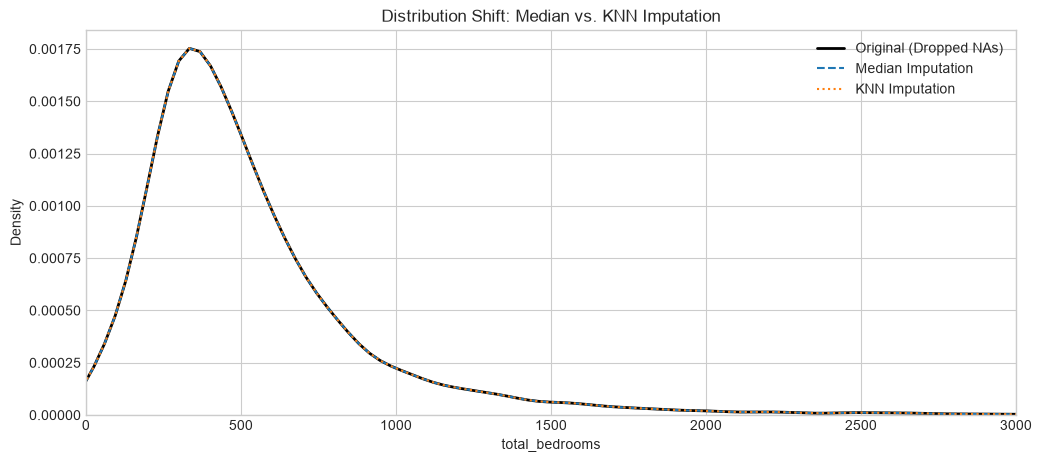

In [6]:
plt.figure(figsize=(12, 5))
plt_sns.kdeplot(missing_col['total_bedrooms'].dropna(), label='Original (Dropped NAs)', color='black', linewidth=2)
plt_sns.kdeplot(median_filled.ravel(), label='Median Imputation', linestyle='--')
plt_sns.kdeplot(knn_bedrooms, label='KNN Imputation', linestyle=':')
plt.xlim(0, 3000)
plt.title("Distribution Shift: Median vs. KNN Imputation")
plt.legend()
plt.show()

In [7]:
from sklearn.preprocessing import FunctionTransformer

def add_extra_features(X):
    
    # Assuming columns: longitude, latitude, housing_median_age, total_rooms(3), total_bedrooms(4), population(5), households(6), median_income
    rooms_per_household = X[:, 3] / X[:, 6]
    bedrooms_per_room = X[:, 4] / X[:, 3]
    population_per_household = X[:, 5] / X[:, 6]
    
    return np.c_[X, rooms_per_household, bedrooms_per_room, population_per_household]

In [8]:
num_attribs = list(X_train.select_dtypes(include=[np.number]).columns)
cat_attribs = ["ocean_proximity"]

In [9]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),       # 1. Fill missing values
    ('attribs_adder', FunctionTransformer(add_extra_features, validate=False)), # 2. Add ratios
    ('power_scaler', PowerTransformer(method='yeo-johnson', standardize=True))  # 3. Fix skewness & scale
])

In [10]:
cat_pipeline = Pipeline([
    # drop='first' will avoid the dummy variable trap!
    ('one_hot', OneHotEncoder(drop='first', handle_unknown='ignore')) 
])

In [11]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [12]:
X_train_prepared = preprocessor.fit_transform(X_train)

# Transform test data (DO NOT FIT on test data)
X_test_prepared = preprocessor.transform(X_test)

print(f"Original Training Shape: {X_train.shape}")
print(f"Transformed Training Shape: {X_train_prepared.shape}")
print("Notice the extra columns! We added 3 ratio features, and the categorical column was One-Hot Encoded.")

Original Training Shape: (16512, 9)
Transformed Training Shape: (16512, 15)
Notice the extra columns! We added 3 ratio features, and the categorical column was One-Hot Encoded.


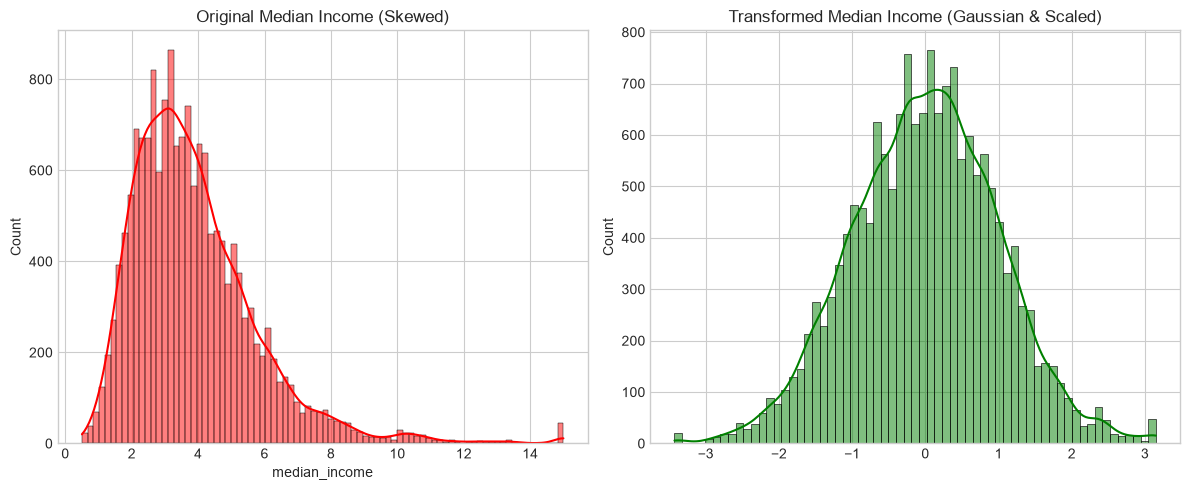

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt_sns.histplot(X_train['median_income'], kde=True, color='red')
plt.title("Original Median Income (Skewed)")

plt.subplot(1, 2, 2)
# 'median_income' is the 8th column (index 7) in the original numeric data
# After processing, its position shifts slightly due to custom features, but we can plot the array directly
plt_sns.histplot(X_train_prepared[:, 7], kde=True, color='green')
plt.title("Transformed Median Income (Gaussian & Scaled)")

plt.tight_layout()
plt.show()

In [14]:
import os
os.makedirs('../artifacts', exist_ok=True)

In [15]:
joblib.dump(preprocessor, '../artifacts/preprocessor.joblib')
print("Preprocessor successfully saved to artifacts/preprocessor.joblib")

Preprocessor successfully saved to artifacts/preprocessor.joblib


In [16]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
print("Train/Test splits saved to data folder.")

Train/Test splits saved to data folder.
